# Random Forest Implementation for Intrusion Detection System

This notebook demonstrates the implementation of a Random Forest classifier for an Intrusion Detection System (IDS) using Sysmon event logs. The model is trained on selected features after preprocessing and feature engineering to optimize performance for IDS-specific criteria.

In [1]:
# pip installs
%pip install "numpy<=2.2" imbalanced-learn tqdm_joblib shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Constants

In [3]:
import os

# Data directory
DATA_DIR = r"e:\danny\IDS_using_ML\StackedAEforIDS\data"

# Checkpointing directory
CHECKPOINT_DIR = r"e:\danny\IDS_using_ML\StackedAEforIDS\checkpointing"

# Paths to CSV files in data folder
EOHT_CSV = os.path.join(DATA_DIR, "LMD-2023 [2.3M Elements - EoHT]checked.csv")
EORS_CSV = os.path.join(DATA_DIR, "LMD-2023 [2.3M Elements - EoRS]checked.csv")
NORMAL_CSV = os.path.join(DATA_DIR, "LMD-2023 [2.3M Elements - Normal]checked.csv")
print("okay")

okay


## Data Loading and Preprocessing

In this section, we load the Sysmon event log datasets from the specified CSV files and perform initial preprocessing steps to prepare the data for feature engineering and model training.

### find out which features exist

In [4]:
import pandas as pd

# Load column names from each CSV file without loading the entire files
eoht_df = pd.read_csv(EOHT_CSV, nrows=1)
eors_df = pd.read_csv(EORS_CSV, nrows=1)
normal_df = pd.read_csv(NORMAL_CSV, nrows=1)

# Get column names from each DataFrame
eoht_columns = set(eoht_df.columns)
eors_columns = set(eors_df.columns)
normal_columns = set(normal_df.columns)

# Find the intersection of all three sets of columns
shared_columns = sorted(list(eoht_columns.intersection(eors_columns).intersection(normal_columns)))

# Display information
print(f"Number of columns in EOHT dataset: {len(eoht_columns)}")
print(f"Number of columns in EORS dataset: {len(eors_columns)}")
print(f"Number of columns in Normal dataset: {len(normal_columns)}")
print(f"Number of shared columns across all datasets: {len(shared_columns)}")
print("\nShared columns:")
for col in shared_columns:
    print(f"- {col}")

Number of columns in EOHT dataset: 95
Number of columns in EORS dataset: 95
Number of columns in Normal dataset: 95
Number of shared columns across all datasets: 95

Shared columns:
- Archived
- CallTrace
- Channel
- CommandLine
- Company
- Computer
- Configuration
- ConfigurationFileHash
- Contents
- Correlation
- CreationUtcTime
- CurrentDirectory
- Description
- DestinationHostname
- DestinationIp
- DestinationIsIpv6
- DestinationPort
- DestinationPortName
- Details
- EventID
- EventRecordID
- EventType
- Execution_ProcessID
- FileVersion
- GrantedAccess
- Guid
- Hash
- Hashes
- ID
- Image
- ImageLoaded
- Initiated
- IntegrityLevel
- IsExecutable
- Keywords
- Label
- Level
- LogonGuid
- LogonId
- Name
- NewThreadId
- Opcode
- OriginalFileName
- ParentCommandLine
- ParentImage
- ParentProcessGuid
- ParentProcessId
- ParentUser
- PipeName
- PreviousCreationUtcTime
- ProcessGuid
- ProcessID
- ProcessId
- Product
- Protocol
- QueryName
- QueryResults
- QueryStatus
- RuleName
- SchemaVer

### Choose and extract features into a single dataframe

In [5]:
# Select base features that actually exist in the datasets
base_features = [
    'Computer',
    'DestinationPortName',
    'EventID',
    'EventRecordID',
    'Execution_ProcessID',
    'Initiated',
    'ProcessId',
    'SourceIsIpv6',
    'SystemTime'  # We'll split this manually into time components
]

print(f"Selected {len(base_features)} base features from the datasets")
print("Base features:", base_features)

Selected 9 base features from the datasets
Base features: ['Computer', 'DestinationPortName', 'EventID', 'EventRecordID', 'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6', 'SystemTime']


In [6]:
# Load the full datasets
print("Loading EOHT dataset...")
eoht_full = pd.read_csv(EOHT_CSV)

print("Loading EORS dataset...")
eors_full = pd.read_csv(EORS_CSV)

print("Loading Normal dataset...")
normal_full = pd.read_csv(NORMAL_CSV)


def extract_time_features(df):
    """Extract time components from SystemTime column"""
    # Convert SystemTime to datetime
    df['SystemTime'] = pd.to_datetime(df['SystemTime'])
    
    # Extract time components
    df['SystemTime_year'] = df['SystemTime'].dt.year
    df['SystemTime_month'] = df['SystemTime'].dt.month
    df['SystemTime_week'] = df['SystemTime'].dt.isocalendar().week
    df['SystemTime_day'] = df['SystemTime'].dt.day
    df['SystemTime_hour'] = df['SystemTime'].dt.hour
    df['SystemTime_minute'] = df['SystemTime'].dt.minute
    df['SystemTime_day_of_week'] = df['SystemTime'].dt.dayofweek
    
    # Drop the original SystemTime column as we've extracted what we need
    df = df.drop('SystemTime', axis=1)
    
    return df

# Extract available features from each dataset
print("\nExtracting features and processing time components...")

# Extract base features
eoht_subset = eoht_full[base_features].copy()
eors_subset = eors_full[base_features].copy()
normal_subset = normal_full[base_features].copy()

# Extract time features for each dataset
print("Processing EOHT time features...")
eoht_subset = extract_time_features(eoht_subset)

print("Processing EORS time features...")
eors_subset = extract_time_features(eors_subset)

print("Processing Normal time features...")
normal_subset = extract_time_features(normal_subset)

# Add labels: 0 for normal, 1 for attacks (eoht or eors)
eoht_subset['label'] = 1  # Attack
eors_subset['label'] = 1  # Attack
normal_subset['label'] = 0  # Normal

print(f"\nDataset sizes after feature extraction:")
print(f"EOHT subset: {eoht_subset.shape}")
print(f"EORS subset: {eors_subset.shape}")
print(f"Normal subset: {normal_subset.shape}")

# Combine all datasets into a single dataframe
combined_df = pd.concat([normal_subset, eoht_subset, eors_subset], ignore_index=True)

print(f"\nCombined dataset shape: {combined_df.shape}")
print(f"Label distribution:")
print(combined_df['label'].value_counts())
print(f"Label distribution (%):")
print(combined_df['label'].value_counts(normalize=True) * 100)

# Display basic info about the combined dataset
print(f"\nCombined dataset info:")
print(f"Total samples: {len(combined_df)}")
print(f"Normal samples (label=0): {len(combined_df[combined_df['label'] == 0])}")
print(f"Attack samples (label=1): {len(combined_df[combined_df['label'] == 1])}")
print(f"Total features (including time components + label): {combined_df.shape[1]}")

# Show column names
print(f"\nFinal features in combined dataset:")
print(list(combined_df.columns))

# Show first few rows
print(f"\nFirst 15 rows of combined dataset:")
combined_df.head(15)

Loading EOHT dataset...


Loading EOHT dataset...


C:\Users\broyd\AppData\Local\Temp\ipykernel_8728\3592157128.py:3: DtypeWarning: Columns (39,52,57,58,59,60,61,64,65,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,86,87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  eoht_full = pd.read_csv(EOHT_CSV)


Loading EOHT dataset...


C:\Users\broyd\AppData\Local\Temp\ipykernel_8728\3592157128.py:3: DtypeWarning: Columns (39,52,57,58,59,60,61,64,65,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,86,87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  eoht_full = pd.read_csv(EOHT_CSV)


...

C:\Users\broyd\AppData\Local\Temp\ipykernel_8728\3592157128.py:6: DtypeWarning: Columns (39,40,41,42,43,44,46,47,48,49,51,52,57,58,59,60,70,71,73,74,75,76,77,78,80,81,82,83,84,86,87,88,90,91) have mixed types. Specify dtype option on import or set low_memory=False.
  eors_full = pd.read_csv(EORS_CSV)


Loading Normal dataset...


C:\Users\broyd\AppData\Local\Temp\ipykernel_8728\3592157128.py:9: DtypeWarning: Columns (39,52,55,56,57,58,59,60,61,64,65,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,86,87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  normal_full = pd.read_csv(NORMAL_CSV)



Extracting features and processing time components...
Processing EOHT time features...
Processing EORS time features...
Processing Normal time features...
Processing Normal time features...

Dataset sizes after feature extraction:
EOHT subset: (135866, 16)
EORS subset: (375239, 16)
Normal subset: (1632903, 16)

Combined dataset shape: (2144008, 16)
Label distribution:
label
0    1632903
1     511105
Name: count, dtype: int64
Label distribution (%):
label
0    76.161236
1    23.838764
Name: proportion, dtype: float64

Combined dataset info:
Total samples: 2144008
Normal samples (label=0): 1632903
Attack samples (label=1): 511105
Total features (including time components + label): 16

Final features in combined dataset:
['Computer', 'DestinationPortName', 'EventID', 'EventRecordID', 'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute', 'SystemTime_day_of_week', 

,Computer,DestinationPortName,EventID,EventRecordID,Execution_ProcessID,Initiated,ProcessId,SourceIsIpv6,SystemTime_year,SystemTime_month,SystemTime_week,SystemTime_day,SystemTime_hour,SystemTime_minute,SystemTime_day_of_week,label
0,LAPTOP-ROPR18AK,netbios-ns,1.0,5382.0,0.0,True,14504.0,False,2021,9,36,7,10,40,1,0
1,LAPTOP-ROPR18AK,0,1.0,5382.0,0.0,0,14504.0,0,2021,9,36,7,10,40,1,0
2,LAPTOP-ROPR18AK,0,3.0,5389.0,0.0,0,4.0,0,2021,9,36,7,10,41,1,0
3,LAPTOP-ROPR18AK,netbios-ns,3.0,5389.0,0.0,True,4.0,False,2021,9,36,7,10,40,1,0
4,WIN-J23NIGGP1Q6.sysmon_set.local,0,4.0,24012.0,0.0,0,0.0,0,2021,9,36,7,10,41,1,0
5,WIN-J23NIGGP1Q6.sysmon_set.local,0,4.0,24012.0,0.0,0,0.0,0,2021,9,36,7,10,41,1,0
6,LAPTOP-ROPR18AK,0,5.0,5387.0,0.0,0,21544.0,0,2021,9,36,7,10,40,1,0
7,LAPTOP-ROPR18AK,0,5.0,5387.0,0.0,0,21544.0,0,2021,9,36,7,10,40,1,0
8,LAPTOP-ROPR18AK,0,16.0,1083.0,0.0,0,0.0,0,2021,9,36,7,10,40,1,0
9,LAPTOP-ROPR18AK,0,16.0,1083.0,0.0,0,0.0,0,2021,9,36,7,10,41,1,0


### scramble the dataframe and perform test/train split

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

# Shuffle the dataframe
combined_df_shuffled = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split features and target
X = combined_df_shuffled.drop('label', axis=1)
y = combined_df_shuffled['label']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training label distribution:")
print(f"Normal (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.2f}%)")
print(f"Attack (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.2f}%)")
print(f"Testing label distribution:")
print(f"Normal (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.2f}%)")
print(f"Attack (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.2f}%)")

Training set shape: (1715206, 15)
Testing set shape: (428802, 15)
Training label distribution:
Normal (0): 1306322 (76.16%)
Attack (1): 408884 (23.84%)
Testing label distribution:
Normal (0): 326581 (76.16%)
Attack (1): 102221 (23.84%)


### Apply preprocessing (fit on train, transform on test)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Features requiring One-Hot Encoding (OHE)
ohe_features = [
    'Computer',                 
    'DestinationPortName',       
    'EventID',                  
    'Initiated',                
    'SourceIsIpv6',             
    'SystemTime_year',          
    'SystemTime_month',         
    'SystemTime_week',          
    'SystemTime_day_of_week'    
]

# Features requiring MinMax Scaling
minmax_features = [
    'EventRecordID',            
    'Execution_ProcessID',      
    'ProcessId',                
    'SystemTime_day',           
    'SystemTime_hour',          
    'SystemTime_minute'         
]

# Ensure consistent dtypes before preprocessing
# Convert categorical features to strings
X_train[ohe_features] = X_train[ohe_features].astype(str)
X_test[ohe_features]  = X_test[ohe_features].astype(str)

# Convert numeric features to floats
X_train[minmax_features] = X_train[minmax_features].apply(pd.to_numeric, errors='coerce')
X_test[minmax_features]  = X_test[minmax_features].apply(pd.to_numeric, errors='coerce')

# (Optional) Inspect resulting dtypes
print("After casting, training dtypes:")
print(pd.concat([X_train[ohe_features].dtypes, X_train[minmax_features].dtypes]))

# Define transformers
ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

minmax_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_transformer, ohe_features),
        ('minmax', minmax_transformer, minmax_features)
    ],
    remainder='drop'  # Drop columns not specified
)

# Fit preprocessor on training data only
print("Fitting preprocessor on training data...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

After casting, training dtypes:
Computer                   object
DestinationPortName        object
EventID                    object
Initiated                  object
SourceIsIpv6               object
SystemTime_year            object
SystemTime_month           object
SystemTime_week            object
SystemTime_day_of_week     object
EventRecordID             float64
Execution_ProcessID       float64
ProcessId                 float64
SystemTime_day              int32
SystemTime_hour             int32
SystemTime_minute           int32
dtype: object
Fitting preprocessor on training data...
Processed training data shape: (1715206, 81)
Processed test data shape: (428802, 81)
Processed training data shape: (1715206, 81)
Processed test data shape: (428802, 81)


## Model Preperation, Hyperparameter search and Training

In [9]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import os
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_fscore_support

import matplotlib.pyplot as plt

# Check if a trained model already exists
rf_model_path = os.path.join(CHECKPOINT_DIR, "random_forest_model.pkl")
grid_results_path = os.path.join(CHECKPOINT_DIR, "grid_search_results.pkl")

if os.path.exists(grid_results_path):
    print(f"Loading existing GridSearch results from {grid_results_path}")
    grid_search = joblib.load(grid_results_path)
    best_model = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best score: {grid_search.best_score_:.4f}")
else:
    print("No existing GridSearch results found. Starting hyperparameter tuning...")
    
    # Create RandomForest classifier with balanced class weights
    rf = RandomForestClassifier(
        random_state=42, 
        n_jobs=1,  
        class_weight='balanced_subsample'  # Handle class imbalance
    )
    
    # Create a pipeline
    pipeline = ImbPipeline([
        ('clf', rf)
    ])
    
    # Define hyperparameter grid - use a smaller grid for faster execution
    param_grid = {
        'clf__n_estimators': [200, 300],
        'clf__max_depth': [20, None],
        'clf__min_samples_split': [2, 5]
    }
    
    # Set up cross-validation with 3 folds for faster execution
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    

    # Create and run the grid search
    start_time = datetime.now()
    print(f"Starting GridSearchCV at {start_time}")

    # compute number of parameter candidates and CV splits
    n_candidates = len(list(ParameterGrid(param_grid)))
    n_splits = cv.get_n_splits(X_train_processed, y_train) 

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',  # F1 score is a good metric for imbalanced datasets
        n_jobs=-1,    
        verbose=2    
    )
    
    with tqdm_joblib(tqdm(desc="GridSearchCV", total= n_candidates * n_splits, unit="fit")):
        grid_search.fit(X_train_processed, y_train)
    
    end_time = datetime.now()
    print(f"GridSearchCV completed in {end_time - start_time}")
    
    # Print the best parameters and score
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best score: {grid_search.best_score_:.4f}")
    
    # Save the grid search results
    joblib.dump(grid_search, grid_results_path)
    print(f"Saved GridSearch results to {grid_results_path}")
    
    # Extract the best model
    best_model = grid_search.best_estimator_

# Save the best model separately for easier loading
joblib.dump(best_model, rf_model_path)
print(f"Saved best model to {rf_model_path}")

Loading existing GridSearch results from e:\danny\IDS_using_ML\StackedAEforIDS\checkpointing\grid_search_results.pkl
Best parameters: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best score: 0.9963
Saved best model to e:\danny\IDS_using_ML\StackedAEforIDS\checkpointing\random_forest_model.pkl
Best parameters: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best score: 0.9963
Saved best model to e:\danny\IDS_using_ML\StackedAEforIDS\checkpointing\random_forest_model.pkl


### Hyperparameter Search Visualisation

Grid Search Results (sorted by performance):
   n_estimators max_depth  min_samples_split  mean_test_score  std_test_score  \
5           300      None                  2         0.996332        0.000089   
4           200      None                  2         0.996316        0.000088   
6           200      None                  5         0.996033        0.000097   
7           300      None                  5         0.996031        0.000083   
1           300        20                  2         0.995909        0.000122   
0           200        20                  2         0.995891        0.000110   
3           300        20                  5         0.995618        0.000078   
2           200        20                  5         0.995610        0.000064   

   rank_test_score  
5                1  
4                2  
6                3  
7                4  
1                5  
0                6  
3                7  
2                8  

Best Hyperparameters:
n_estimators:

Grid Search Results (sorted by performance):
   n_estimators max_depth  min_samples_split  mean_test_score  std_test_score  \
5           300      None                  2         0.996332        0.000089   
4           200      None                  2         0.996316        0.000088   
6           200      None                  5         0.996033        0.000097   
7           300      None                  5         0.996031        0.000083   
1           300        20                  2         0.995909        0.000122   
0           200        20                  2         0.995891        0.000110   
3           300        20                  5         0.995618        0.000078   
2           200        20                  5         0.995610        0.000064   

   rank_test_score  
5                1  
4                2  
6                3  
7                4  
1                5  
0                6  
3                7  
2                8  

Best Hyperparameters:
n_estimators:

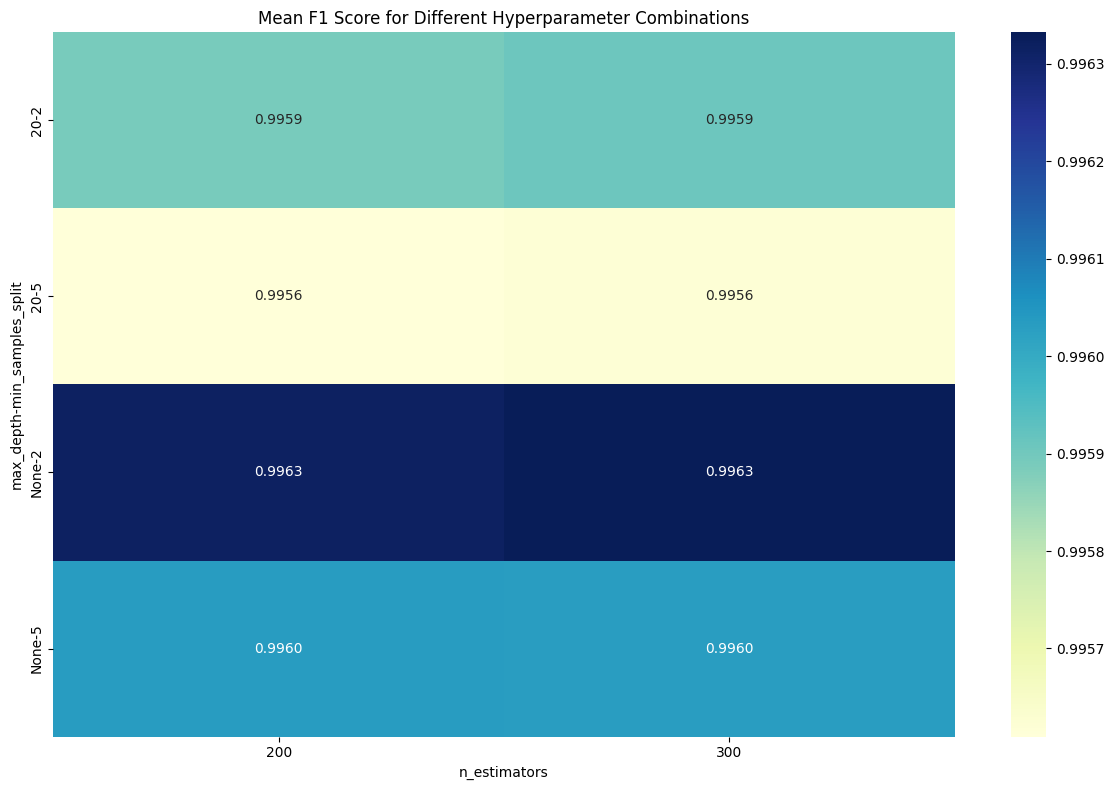

In [10]:
import pandas as pd
import seaborn as sns

# Visualize and analyze Grid Search results
import matplotlib.pyplot as plt

# Extract the cross-validation results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Create a more readable dataframe with parameters and scores
results_df = pd.DataFrame({
    'n_estimators': cv_results['param_clf__n_estimators'],
    'max_depth': cv_results['param_clf__max_depth'].apply(lambda x: 'None' if x is None else x),
    'min_samples_split': cv_results['param_clf__min_samples_split'],
    'mean_test_score': cv_results['mean_test_score'],
    'std_test_score': cv_results['std_test_score'],
    'rank_test_score': cv_results['rank_test_score']
})

# Sort by performance (best first)
results_df = results_df.sort_values('rank_test_score')

# Display the results table
print("Grid Search Results (sorted by performance):")
print(results_df)

# Create a heatmap to visualize parameter combinations
plt.figure(figsize=(12, 8))
pivot_table = pd.pivot_table(
    results_df, 
    values='mean_test_score', 
    index=['max_depth', 'min_samples_split'],
    columns=['n_estimators']
)

sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title('Mean F1 Score for Different Hyperparameter Combinations')
plt.tight_layout()

# Display the best hyperparameters and their performance
print(f"\nBest Hyperparameters:")
print(f"n_estimators: {best_model['clf'].n_estimators}")
print(f"max_depth: {best_model['clf'].max_depth}")
print(f"min_samples_split: {best_model['clf'].min_samples_split}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

## Results

Applying model to test data...
Model Performance on Test Data:
Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9950
F1 Score: 0.9967

Confusion Matrix:
TN: 326419, FP: 162
FN: 513, TP: 101708
Model Performance on Test Data:
Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9950
F1 Score: 0.9967

Confusion Matrix:
TN: 326419, FP: 162
FN: 513, TP: 101708


Applying model to test data...
Model Performance on Test Data:
Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9950
F1 Score: 0.9967

Confusion Matrix:
TN: 326419, FP: 162
FN: 513, TP: 101708
Model Performance on Test Data:
Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9950
F1 Score: 0.9967

Confusion Matrix:
TN: 326419, FP: 162
FN: 513, TP: 101708


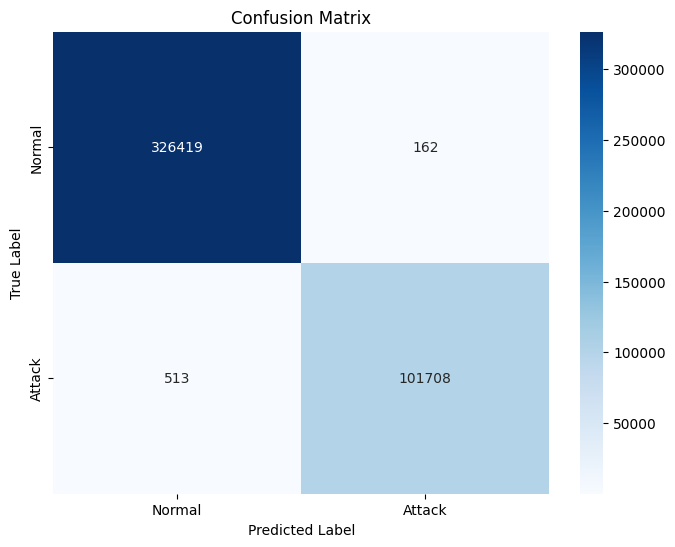

Applying model to test data...
Model Performance on Test Data:
Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9950
F1 Score: 0.9967

Confusion Matrix:
TN: 326419, FP: 162
FN: 513, TP: 101708
Model Performance on Test Data:
Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9950
F1 Score: 0.9967

Confusion Matrix:
TN: 326419, FP: 162
FN: 513, TP: 101708


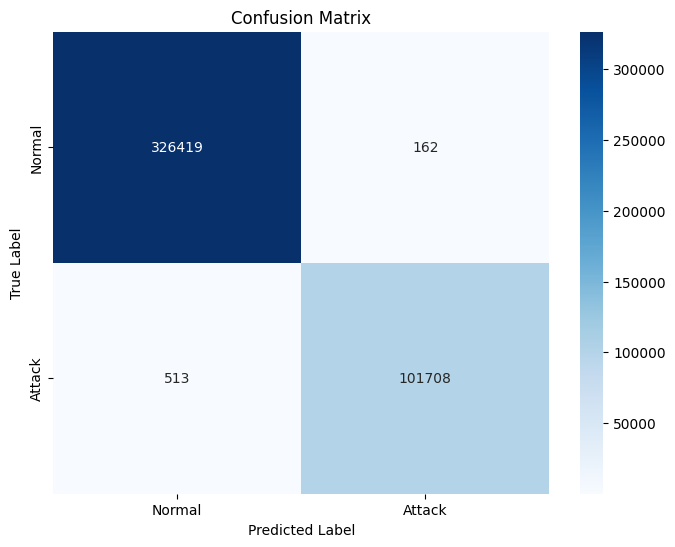


Number of False Positives: 162
Number of False Negatives: 513

# Analysis of Detection Errors

## False Positive Error Analysis (Top 10 Examples)
These normal log events were incorrectly classified as attacks:


,Computer,DestinationPortName,EventID,EventRecordID,Execution_ProcessID,Initiated,ProcessId,SourceIsIpv6,SystemTime_year,SystemTime_month,SystemTime_week,SystemTime_day,SystemTime_hour,SystemTime_minute,SystemTime_day_of_week
2715,WINDOWS10EVAL.stefania.local,0,1.0,36011.0,0.0,0,692.0,0,2021,9,36,7,11,34,1
3687,WIN-J23NIGGP1Q6.sysmon_set.local,0,1.0,24068.0,3120.0,0,2612.0,0,2022,11,45,12,15,54,5
5159,WINDOWS10EVAL.stefania.local,0,1.0,17886.0,0.0,0,1840.0,0,2021,9,36,7,16,36,1
13162,WIN-J23NIGGP1Q6.sysmon_set.local,0,1.0,21809.0,0.0,0,2584.0,0,2021,9,36,11,0,14,5
16537,WIN-J23NIGGP1Q6.sysmon_set.local,0,1.0,22039.0,0.0,0,3732.0,0,2021,9,36,11,0,6,5
19263,WINDOWS10EVAL.stefania.local,0,1.0,11469.0,0.0,0,4008.0,0,2021,9,36,7,18,23,1
21010,WINDOWS10EVAL.stefania.local,0,22.0,10255.0,0.0,0,7220.0,0,2021,9,36,7,18,44,1
22687,WINDOWS10EVAL.stefania.local,0,1.0,13940.0,0.0,0,676.0,0,2021,9,36,7,21,38,1
34415,WINDOWS10EVAL.stefania.local,0,13.0,12699.0,0.0,0,608.0,0,2021,9,36,7,18,3,1
35398,WIN-J23NIGGP1Q6.sysmon_set.local,0,1.0,25640.0,0.0,0,6116.0,0,2021,9,36,10,22,39,4



## False Negative Error Analysis (Top 10 Examples)
These attack log events were incorrectly classified as normal:


,Computer,DestinationPortName,EventID,EventRecordID,Execution_ProcessID,Initiated,ProcessId,SourceIsIpv6,SystemTime_year,SystemTime_month,SystemTime_week,SystemTime_day,SystemTime_hour,SystemTime_minute,SystemTime_day_of_week
471,WINDOWS10EVAL.stefania.local,0,1.0,26205.0,0.0,0,704.0,0,2021,9,36,7,14,17,1
560,WINDOWS10EVAL.stefania.local,0,13.0,490.0,0.0,0,1008.0,0,2021,9,36,8,1,22,2
784,WINDOWS10EVAL.stefania.local,0,3.0,19607.0,0.0,0,3976.0,0,2021,9,36,7,16,8,1
980,WINDOWS10EVAL.stefania.local,0,22.0,5095.0,0.0,0,4704.0,0,2021,9,36,8,0,5,2
1466,WINDOWS10EVAL.stefania.local,0,3.0,621.0,0.0,0,5316.0,0,2021,9,36,7,21,23,1
2267,WINDOWS10EVAL.stefania.local,0,1.0,10152.0,0.0,0,4484.0,0,2021,9,36,7,18,44,1
2944,WINDOWS10EVAL.stefania.local,0,1.0,6604.0,0.0,0,6044.0,0,2021,9,36,7,19,44,1
3304,WINDOWS10EVAL.stefania.local,0,1.0,16352.0,0.0,0,1444.0,0,2021,9,36,7,17,2,1
3796,WINDOWS10EVAL.stefania.local,0,13.0,18855.0,0.0,0,716.0,0,2021,9,36,7,16,20,1
4983,WINDOWS10EVAL.stefania.local,0,1.0,4906.0,0.0,0,108.0,0,2021,9,36,8,0,9,2


In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Make predictions on the test data
print("Applying model to test data...")
y_pred = best_model.predict(X_test_processed)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

print(f"Model Performance on Test Data:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Find misclassified examples
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred)

# Identify False Positives (predicted 1, actual 0)
fp_mask = (y_pred_series == 1) & (y_test_reset == 0)
fp_indices = fp_mask[fp_mask].index

# Identify False Negatives (predicted 0, actual 1)
fn_mask = (y_pred_series == 0) & (y_test_reset == 1)
fn_indices = fn_mask[fn_mask].index

print(f"\nNumber of False Positives: {len(fp_indices)}")
print(f"Number of False Negatives: {len(fn_indices)}")

# Analysis of detection errors
print("\n# Analysis of Detection Errors")

# 1. False Positive Analysis
if not fp_indices.empty:
    print("\n## False Positive Error Analysis (Top 10 Examples)")
    print("These normal log events were incorrectly classified as attacks:")
    # Get the first 10 false positive examples
    fp_examples_df = X_test_reset.loc[fp_indices].head(10)
    # Display them as a table
    display(fp_examples_df)
else:
    print("\nNo False Positives found in the test set.")

# 2. False Negative Analysis
if not fn_indices.empty:
    print("\n## False Negative Error Analysis (Top 10 Examples)")
    print("These attack log events were incorrectly classified as normal:")
    # Get the first 10 false negative examples
    fn_examples_df = X_test_reset.loc[fn_indices].head(10)
    # Display them as a table
    display(fn_examples_df)
else:
    print("\nNo False Negatives found in the test set.")
    

### Correctly Classified Examples

In [17]:
# Analysis of correctly classified examples
print("\n# Analysis of Correctly Classified Examples")

# Identify True Positives (predicted 1, actual 1)
tp_mask = (y_pred_series == 1) & (y_test_reset == 1)
tp_indices = tp_mask[tp_mask].index

# Identify True Negatives (predicted 0, actual 0)
tn_mask = (y_pred_series == 0) & (y_test_reset == 0)
tn_indices = tn_mask[tn_mask].index

print(f"\nNumber of True Positives: {len(tp_indices)}")
print(f"Number of True Negatives: {len(tn_indices)}")

# 1. True Positive Analysis (Correctly identified attacks)
if not tp_indices.empty:
    print("\n## Correctly Classified Attacks (Top 10 Examples)")
    print("These attack log events were correctly classified as attacks:")
    # Get the first 10 true positive examples
    tp_examples_df = X_test_reset.loc[tp_indices].head(10)
    # Display them as a table
    display(tp_examples_df)
else:
    print("\nNo True Positives found in the test set.")

# 2. True Negative Analysis (Correctly identified normal events)
if not tn_indices.empty:
    print("\n## Correctly Classified Normal Events (Top 10 Examples)")
    print("These normal log events were correctly classified as normal:")
    # Get the first 10 true negative examples
    tn_examples_df = X_test_reset.loc[tn_indices].head(10)
    # Display them as a table
    display(tn_examples_df)
else:
    print("\nNo True Negatives found in the test set.")


# Analysis of Correctly Classified Examples

Number of True Positives: 101708
Number of True Negatives: 326419

## Correctly Classified Attacks (Top 10 Examples)
These attack log events were correctly classified as attacks:


,Computer,DestinationPortName,EventID,EventRecordID,Execution_ProcessID,Initiated,ProcessId,SourceIsIpv6,SystemTime_year,SystemTime_month,SystemTime_week,SystemTime_day,SystemTime_hour,SystemTime_minute,SystemTime_day_of_week
3,win-dc-800.attackrange.local,0,10.0,23268.0,0.0,0,0.0,0,2021,9,36,10,8,8,4
5,win-host-987.attackrange.local,0,10.0,59077074.0,0.0,0,0.0,0,2021,9,36,8,18,24,2
6,win-host-987.attackrange.local,-,3.0,59037796.0,0.0,True,5272.0,False,2021,9,36,9,9,5,3
13,win-host-987.attackrange.local,0,23.0,59036830.0,0.0,0,5780.0,0,2021,9,36,9,0,34,3
21,win-dc-800.attackrange.local,0,10.0,28992.0,0.0,0,0.0,0,2023,12,49,7,10,54,3
26,win-dc-800.attackrange.local,0,10.0,28176.0,0.0,0,0.0,0,2023,12,49,7,15,14,3
27,win-dc-128.attackrange.local,0,7.0,485207635.0,0.0,0,5480.0,0,2021,9,36,9,15,58,3
29,win-dc-128.attackrange.local,-,3.0,150682939.0,0.0,True,4044.0,False,2023,12,49,8,5,51,4
31,WIN-J23NIGGP1Q6.sysmon_set.local,llmnr,3.0,15254.0,2916.0,True,1224.0,False,2022,11,45,13,1,12,6
33,win-dc-128.attackrange.local,0,7.0,115923270.0,0.0,0,6896.0,0,2023,12,49,6,5,51,2



# Analysis of Correctly Classified Examples

Number of True Positives: 101708
Number of True Negatives: 326419

## Correctly Classified Attacks (Top 10 Examples)
These attack log events were correctly classified as attacks:


,Computer,DestinationPortName,EventID,EventRecordID,Execution_ProcessID,Initiated,ProcessId,SourceIsIpv6,SystemTime_year,SystemTime_month,SystemTime_week,SystemTime_day,SystemTime_hour,SystemTime_minute,SystemTime_day_of_week
3,win-dc-800.attackrange.local,0,10.0,23268.0,0.0,0,0.0,0,2021,9,36,10,8,8,4
5,win-host-987.attackrange.local,0,10.0,59077074.0,0.0,0,0.0,0,2021,9,36,8,18,24,2
6,win-host-987.attackrange.local,-,3.0,59037796.0,0.0,True,5272.0,False,2021,9,36,9,9,5,3
13,win-host-987.attackrange.local,0,23.0,59036830.0,0.0,0,5780.0,0,2021,9,36,9,0,34,3
21,win-dc-800.attackrange.local,0,10.0,28992.0,0.0,0,0.0,0,2023,12,49,7,10,54,3
26,win-dc-800.attackrange.local,0,10.0,28176.0,0.0,0,0.0,0,2023,12,49,7,15,14,3
27,win-dc-128.attackrange.local,0,7.0,485207635.0,0.0,0,5480.0,0,2021,9,36,9,15,58,3
29,win-dc-128.attackrange.local,-,3.0,150682939.0,0.0,True,4044.0,False,2023,12,49,8,5,51,4
31,WIN-J23NIGGP1Q6.sysmon_set.local,llmnr,3.0,15254.0,2916.0,True,1224.0,False,2022,11,45,13,1,12,6
33,win-dc-128.attackrange.local,0,7.0,115923270.0,0.0,0,6896.0,0,2023,12,49,6,5,51,2



## Correctly Classified Normal Events (Top 10 Examples)
These normal log events were correctly classified as normal:


,Computer,DestinationPortName,EventID,EventRecordID,Execution_ProcessID,Initiated,ProcessId,SourceIsIpv6,SystemTime_year,SystemTime_month,SystemTime_week,SystemTime_day,SystemTime_hour,SystemTime_minute,SystemTime_day_of_week
0,LAPTOP-ROPR18AK,netbios-dgm,3.0,2219.0,0.0,False,4.0,False,2022,10,41,13,16,19,3
1,LAPTOP-ROPR18AK,netbios-ns,3.0,1502.0,5520.0,True,4.0,False,2023,12,49,5,2,3,1
2,LAPTOP-ROPR18AK,netbios-dgm,3.0,3769.0,0.0,True,4.0,False,2022,10,41,11,8,26,1
4,LAPTOP-ROPR18AK,netbios-dgm,3.0,3435.0,5520.0,True,4.0,False,2023,11,48,27,13,5,0
7,LAPTOP-ROPR18AK,netbios-ns,3.0,4059.0,5520.0,True,4.0,False,2023,11,48,29,3,14,2
8,LAPTOP-ROPR18AK,netbios-ns,3.0,4578.0,5676.0,True,4.0,False,2022,11,45,13,22,28,6
9,LAPTOP-ROPR18AK,0,5.0,1269.0,5520.0,0,9308.0,0,2022,11,46,14,12,31,0
10,LAPTOP-ROPR18AK,netbios-ns,3.0,4916.0,5676.0,True,4.0,False,2023,11,48,27,20,14,0
11,LAPTOP-ROPR18AK,netbios-dgm,3.0,2352.0,5520.0,False,4.0,False,2022,11,46,14,22,18,0
12,LAPTOP-ROPR18AK,netbios-ns,3.0,4675.0,5676.0,True,4.0,False,2023,11,48,27,20,18,0


### Feature importance analysis

Top 20 Most Important Features:
                                  Feature  Importance
75                          EventRecordID    0.182823
0                Computer_LAPTOP-ROPR18AK    0.145375
42                            EventID_3.0    0.069875
52                     SourceIsIpv6_False    0.062536
77                              ProcessId    0.059811
9                   DestinationPortName_0    0.054301
51                         SourceIsIpv6_0    0.054098
78                         SystemTime_day    0.052360
48                            Initiated_0    0.047621
76                    Execution_ProcessID    0.032828
3   Computer_win-dc-128.attackrange.local    0.022527
55                   SystemTime_year_2022    0.021010
23        DestinationPortName_netbios-dgm    0.019271
30                           EventID_10.0    0.017330
2   Computer_WINDOWS10EVAL.stefania.local    0.014008
44                            EventID_5.0    0.013661
58                    SystemTime_month_11    0.012

Top 20 Most Important Features:
                                  Feature  Importance
75                          EventRecordID    0.182823
0                Computer_LAPTOP-ROPR18AK    0.145375
42                            EventID_3.0    0.069875
52                     SourceIsIpv6_False    0.062536
77                              ProcessId    0.059811
9                   DestinationPortName_0    0.054301
51                         SourceIsIpv6_0    0.054098
78                         SystemTime_day    0.052360
48                            Initiated_0    0.047621
76                    Execution_ProcessID    0.032828
3   Computer_win-dc-128.attackrange.local    0.022527
55                   SystemTime_year_2022    0.021010
23        DestinationPortName_netbios-dgm    0.019271
30                           EventID_10.0    0.017330
2   Computer_WINDOWS10EVAL.stefania.local    0.014008
44                            EventID_5.0    0.013661
58                    SystemTime_month_11    0.012

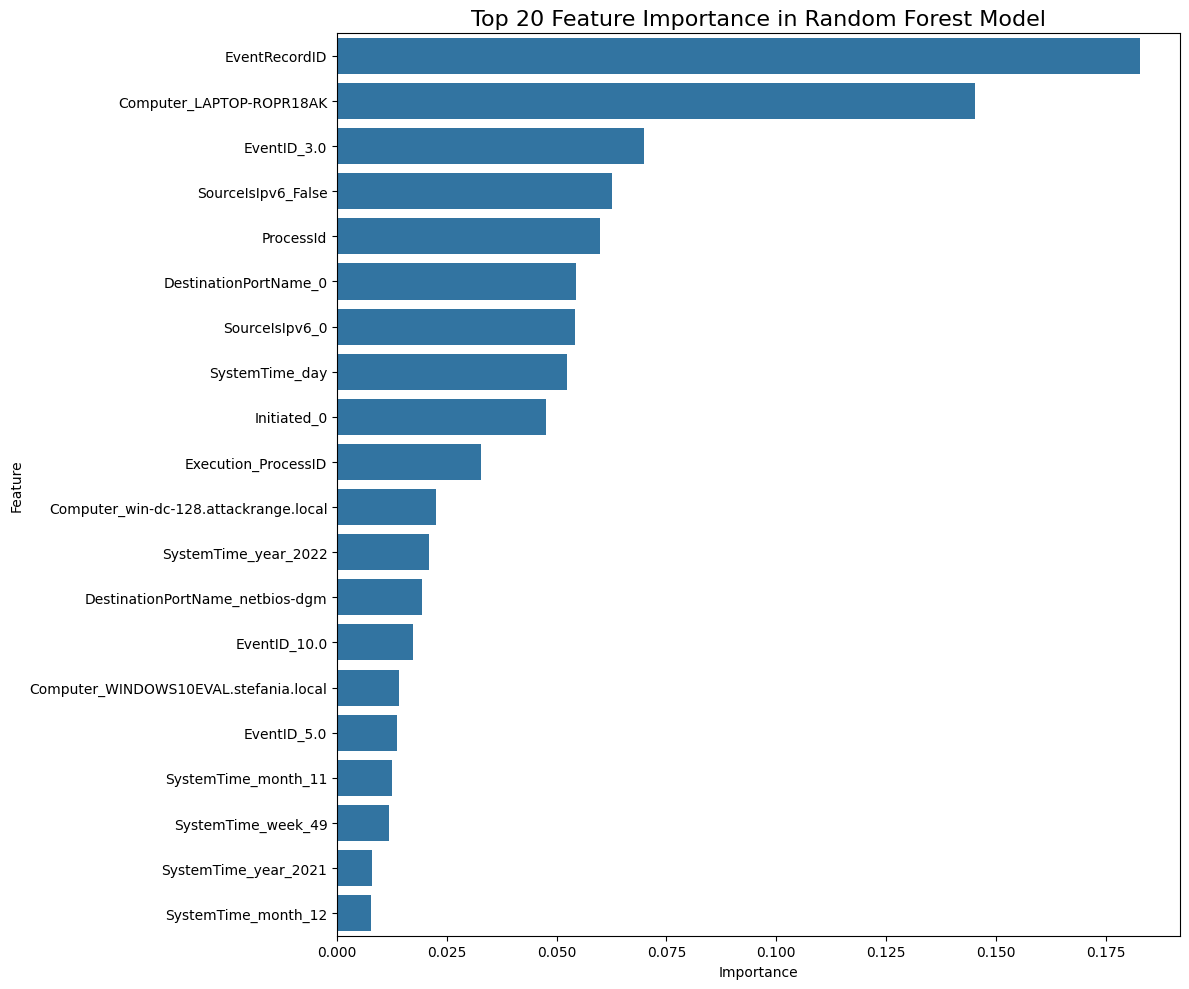

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns

# Feature Importance and SHAP Analysis
import matplotlib.pyplot as plt

# Extract feature names from preprocessor
feature_names = []
# Get one-hot encoded feature names
for name, encoder, cols in preprocessor.transformers_:
    if name == 'ohe':
        for i, col in enumerate(cols):
            for cat in encoder.named_steps['onehot'].categories_[i]:
                feature_names.append(f"{col}_{cat}")
    elif name == 'minmax':
        feature_names.extend(cols)

# Get feature importances
importances = best_model['clf'].feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display top 20 most important features
print("Top 20 Most Important Features:")
print(feature_importance_df.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importance in Random Forest Model', fontsize=16)
plt.tight_layout()
plt.show()

In [27]:
# Save classification mistake analysis results
import os

print("Saving classification mistake analysis variables...")

# Save False Negative examples (attacks misclassified as normal)
if 'fn_examples_df' in locals():
    fn_examples_df.to_csv(os.path.join(CHECKPOINT_DIR, 'rf_false_negatives.csv'), index=False)
    print(f"✓ Saved false negative examples: {len(fn_examples_df)} records")

# Save False Positive examples (normal traffic misclassified as attacks)  
if 'fp_examples_df' in locals():
    fp_examples_df.to_csv(os.path.join(CHECKPOINT_DIR, 'rf_false_positives.csv'), index=False)
    print(f"✓ Saved false positive examples: {len(fp_examples_df)} records")


Saving classification mistake analysis variables...
✓ Saved false negative examples: 10 records
✓ Saved false positive examples: 10 records


In [32]:
# Cross-Model Comparison: Test Random Forest on other models' mistake examples
import pandas as pd
import os

print("=== Cross-Model Comparison: Random Forest vs Other Models ===\n")

# Load saved mistake examples from other models
try:
    # Load Stacked AE mistake examples
    ae_fn_df = pd.read_csv(os.path.join(CHECKPOINT_DIR, 'stacked_ae_false_negatives.csv'))
    ae_fp_df = pd.read_csv(os.path.join(CHECKPOINT_DIR, 'stacked_ae_false_positives.csv'))
    
    # Load VAE mistake examples
    vae_fn_df = pd.read_csv(os.path.join(CHECKPOINT_DIR, 'vae_false_negatives.csv'))
    vae_fp_df = pd.read_csv(os.path.join(CHECKPOINT_DIR, 'vae_false_positives.csv'))
    
    print("✓ Successfully loaded mistake examples from other models")
    
    # Function to test Random Forest on examples
    def test_rf_on_examples(df, original_model, mistake_type, true_label):
        if len(df) == 0:
            print(f"No {mistake_type} examples from {original_model}")
            return
            
        # Preprocess the examples using the same preprocessor
        df_processed = preprocessor.transform(df)
        
        # Make predictions with Random Forest
        rf_predictions = best_model.predict(df_processed)
        
        # Count agreements and disagreements
        correct_predictions = (rf_predictions == true_label).sum()
        total_examples = len(df)
        
        print(f"\n{original_model} {mistake_type} Examples (n={total_examples}):")
        print(f"Random Forest correctly classifies: {correct_predictions}/{total_examples} ({correct_predictions/total_examples*100:.1f}%)")
        print(f"Random Forest also makes mistakes: {total_examples-correct_predictions}/{total_examples} ({(total_examples-correct_predictions)/total_examples*100:.1f}%)")
        
        return {
            'model': original_model,
            'mistake_type': mistake_type,
            'total_examples': total_examples,
            'rf_correct': correct_predictions,
            'rf_incorrect': total_examples - correct_predictions,
            'rf_accuracy': correct_predictions / total_examples
        }
    
    # Test Random Forest on other models' mistakes
    results = []
    
    # Test on Stacked AE mistakes
    results.append(test_rf_on_examples(ae_fn_df, "Stacked AE", "False Negatives", 1))  # True label = Attack
    results.append(test_rf_on_examples(ae_fp_df, "Stacked AE", "False Positives", 0))  # True label = Normal
    
    # Test on VAE mistakes
    results.append(test_rf_on_examples(vae_fn_df, "VAE", "False Negatives", 1))  # True label = Attack
    results.append(test_rf_on_examples(vae_fp_df, "VAE", "False Positives", 0))  # True label = Normal
    
    # Create summary table
    results_df = pd.DataFrame([r for r in results if r is not None])
    
    if len(results_df) > 0:
        print("\n" + "="*60)
        print("SUMMARY: Random Forest Performance on Other Models' Mistakes")
        print("="*60)
        print(results_df.to_string(index=False))

        
        # Analyze specific examples of agreement/disagreement
        print("\n" + "="*70)
        print("DETAILED EXAMPLE ANALYSIS")
        print("="*70)
        
        def find_and_display_example(mistake_df, original_model, mistake_type, agreement_type):
            """Find and display specific examples of agreement/disagreement"""
            
            if len(mistake_df) == 0:
                print(f"No {mistake_type} examples from {original_model}")
                return
                
            # Preprocess the examples
            df_processed = preprocessor.transform(mistake_df)
            rf_predictions = best_model.predict(df_processed)
            
            # Determine true label based on mistake type
            true_label = 1 if mistake_type == "False Negatives" else 0
            
            # Find agreement/disagreement
            rf_correct = (rf_predictions == true_label)
            
            if agreement_type == "agreement":
                # RF also makes the same mistake
                target_indices = mistake_df.index[~rf_correct]
                title = f"RF AGREES with {original_model} ({mistake_type})"
                description = f"Both models incorrectly classify this sample"
            else:  # disagreement
                # RF gets it right where original model failed
                target_indices = mistake_df.index[rf_correct]
                title = f"RF DISAGREES with {original_model} ({mistake_type})"
                description = f"RF correctly classifies what {original_model} missed"
            
            if len(target_indices) > 0:
                # Display three examples
                for i in range(min(3, len(target_indices))):
                    example = mistake_df.loc[target_indices[i]]
                    rf_pred = rf_predictions[mistake_df.index.get_loc(target_indices[i])]

                    print(f"\n{title} (Example {i+1})")
                    print("-" * len(title))
                    print(f"{description}")
                    print(f"True Label: {true_label} | RF Prediction: {rf_pred}")
                    print("\nSample Details:")
                    display(example)
                    for col, val in example.items():
                        if col not in ['error_type', 'error_score', 'sample_id', 'true_label', 'pred_label']:
                            print(f"  {col}: {val}")
                
                return True
            else:
                print(f"\nNo examples found where RF {agreement_type}s with {original_model} on {mistake_type}")
                return False
        
        # Find examples for each scenario
        print("\n1. Examples where Random Forest AGREES with other models (makes same mistakes):")
        find_and_display_example(ae_fn_df, "Stacked AE", "False Negatives", "agreement")
        find_and_display_example(vae_fp_df, "VAE", "False Positives", "agreement")
        
        print("\n2. Examples where Random Forest DISAGREES with other models (corrects their mistakes):")
        find_and_display_example(ae_fp_df, "Stacked AE", "False Positives", "disagreement")  
        find_and_display_example(vae_fn_df, "VAE", "False Negatives", "disagreement")

except FileNotFoundError as e:
    print("Make sure you have run the other notebooks and saved their mistake examples first.")



=== Cross-Model Comparison: Random Forest vs Other Models ===

✓ Successfully loaded mistake examples from other models

Stacked AE False Negatives Examples (n=10):
Random Forest correctly classifies: 4/10 (40.0%)
Random Forest also makes mistakes: 6/10 (60.0%)

Stacked AE False Positives Examples (n=10):
Random Forest correctly classifies: 8/10 (80.0%)
Random Forest also makes mistakes: 2/10 (20.0%)

VAE False Negatives Examples (n=10):
Random Forest correctly classifies: 5/10 (50.0%)
Random Forest also makes mistakes: 5/10 (50.0%)

VAE False Positives Examples (n=10):
Random Forest correctly classifies: 7/10 (70.0%)
Random Forest also makes mistakes: 3/10 (30.0%)

SUMMARY: Random Forest Performance on Other Models' Mistakes
     model    mistake_type  total_examples  rf_correct  rf_incorrect  rf_accuracy
Stacked AE False Negatives              10           4             6          0.4
Stacked AE False Positives              10           8             2          0.8
       VAE False N

Computer                  WINDOWS10EVAL.stefania.local
DestinationPortName                                  0
EventID                                            1.0
EventRecordID                                  30041.0
Execution_ProcessID                                0.0
Initiated                                            0
ProcessId                                       4560.0
SourceIsIpv6                                         0
SystemTime_year                                   2021
SystemTime_month                                     9
SystemTime_week                                     36
SystemTime_day                                       7
SystemTime_hour                                     13
SystemTime_minute                                   14
SystemTime_day_of_week                               1
Name: 0, dtype: object

  Computer: WINDOWS10EVAL.stefania.local
  DestinationPortName: 0
  EventID: 1.0
  EventRecordID: 30041.0
  Execution_ProcessID: 0.0
  Initiated: 0
  ProcessId: 4560.0
  SourceIsIpv6: 0
  SystemTime_year: 2021
  SystemTime_month: 9
  SystemTime_week: 36
  SystemTime_day: 7
  SystemTime_hour: 13
  SystemTime_minute: 14
  SystemTime_day_of_week: 1

RF AGREES with Stacked AE (False Negatives) (Example 2)
-------------------------------------------
Both models incorrectly classify this sample
True Label: 1 | RF Prediction: 0

Sample Details:


Computer                  WINDOWS10EVAL.stefania.local
DestinationPortName                                  0
EventID                                            1.0
EventRecordID                                  30075.0
Execution_ProcessID                                0.0
Initiated                                            0
ProcessId                                       4116.0
SourceIsIpv6                                         0
SystemTime_year                                   2021
SystemTime_month                                     9
SystemTime_week                                     36
SystemTime_day                                       7
SystemTime_hour                                     13
SystemTime_minute                                   13
SystemTime_day_of_week                               1
Name: 1, dtype: object

  Computer: WINDOWS10EVAL.stefania.local
  DestinationPortName: 0
  EventID: 1.0
  EventRecordID: 30075.0
  Execution_ProcessID: 0.0
  Initiated: 0
  ProcessId: 4116.0
  SourceIsIpv6: 0
  SystemTime_year: 2021
  SystemTime_month: 9
  SystemTime_week: 36
  SystemTime_day: 7
  SystemTime_hour: 13
  SystemTime_minute: 13
  SystemTime_day_of_week: 1

RF AGREES with Stacked AE (False Negatives) (Example 3)
-------------------------------------------
Both models incorrectly classify this sample
True Label: 1 | RF Prediction: 0

Sample Details:


...

  Computer: WIN-J23NIGGP1Q6.sysmon_set.local
  DestinationPortName: -
  EventID: 3.0
  EventRecordID: 22858.0
  Execution_ProcessID: 3052.0
  Initiated: False
  ProcessId: 1232.0
  SourceIsIpv6: False
  SystemTime_year: 2022
  SystemTime_month: 11
  SystemTime_week: 45
  SystemTime_day: 12
  SystemTime_hour: 16
  SystemTime_minute: 27
  SystemTime_day_of_week: 5

RF DISAGREES with VAE (False Negatives) (Example 2)
---------------------------------------
RF correctly classifies what VAE missed
True Label: 1 | RF Prediction: 1

Sample Details:


Computer                  WIN-J23NIGGP1Q6.sysmon_set.local
DestinationPortName                                      -
EventID                                                3.0
EventRecordID                                      22849.0
Execution_ProcessID                                 3052.0
Initiated                                            False
ProcessId                                           1232.0
SourceIsIpv6                                         False
SystemTime_year                                       2022
SystemTime_month                                        11
SystemTime_week                                         45
SystemTime_day                                          12
SystemTime_hour                                         16
SystemTime_minute                                       28
SystemTime_day_of_week                                   5
Name: 4, dtype: object

  Computer: WIN-J23NIGGP1Q6.sysmon_set.local
  DestinationPortName: -
  EventID: 3.0
  EventRecordID: 22849.0
  Execution_ProcessID: 3052.0
  Initiated: False
  ProcessId: 1232.0
  SourceIsIpv6: False
  SystemTime_year: 2022
  SystemTime_month: 11
  SystemTime_week: 45
  SystemTime_day: 12
  SystemTime_hour: 16
  SystemTime_minute: 28
  SystemTime_day_of_week: 5

RF DISAGREES with VAE (False Negatives) (Example 3)
---------------------------------------
RF correctly classifies what VAE missed
True Label: 1 | RF Prediction: 1

Sample Details:


Computer                  WIN-J23NIGGP1Q6.sysmon_set.local
DestinationPortName                                      -
EventID                                                3.0
EventRecordID                                      22849.0
Execution_ProcessID                                 3052.0
Initiated                                            False
ProcessId                                           1232.0
SourceIsIpv6                                         False
SystemTime_year                                       2022
SystemTime_month                                        11
SystemTime_week                                         45
SystemTime_day                                          12
SystemTime_hour                                         16
SystemTime_minute                                       27
SystemTime_day_of_week                                   5
Name: 6, dtype: object

  Computer: WIN-J23NIGGP1Q6.sysmon_set.local
  DestinationPortName: -
  EventID: 3.0
  EventRecordID: 22849.0
  Execution_ProcessID: 3052.0
  Initiated: False
  ProcessId: 1232.0
  SourceIsIpv6: False
  SystemTime_year: 2022
  SystemTime_month: 11
  SystemTime_week: 45
  SystemTime_day: 12
  SystemTime_hour: 16
  SystemTime_minute: 27
  SystemTime_day_of_week: 5
